# **Air Quality Data Modeling**

## ST563 Midterm Project

### Kajal Gupta, Teddie Hall, Nan Liu, Alysia Yan

The [Air Quality dataset](https://archive.ics.uci.edu/dataset/360/air+quality) comes from the UC Irvine Machine Learning Repository. The [paper](https://www.sciencedirect.com/science/article/abs/pii/S0925400507007691?via%3Dihub) introducing this dataset explains that it contains a series of sensor measurements for various gases used to evaluate air quality. The original context of this data was an experiment comparing the performance of a novel multi-sensor device developed by Pirelli Labs with a set of sensors owned by the Lombardy Regional Agency for Environmental Protection (ARPA). We will refer to the set of sensors in the novel device as the experimental sensor group and the set of sensors in the ARPA monitoring station as the conventional sensor group. Both groups of sensors were located in the same place on a busy street in an Italian city and collected data for about one year (3/10/2004 - 4/04/2005).

#### Variables
*   **Date**
*   **Time**
*   **CO(GT)**: carbon monoxide measurement, conventional sensor group
*   **PT08.S1(CO)**: carbon monoxide measurement, experimental sensor group
*   **NMHC(GT)**: non-methane hydrocarbons measurement, conventional sensor group
*   **PT08.S2(NMHC)**: non-methane hydrocarbons measurement, experimental sensor group
*   **NOx(GT)**: nitrogen oxide measurement, conventional sensor group
*   **PT08.S3(NOx)**: nitrogen oxide measurement, experimental sensor group
*   **NO2(GT)**: nitrogen dioxide measurement, conventional sensor group
*   **PT08.S4(NO2)**: nitrogen dioxide measurement, experimental sensor group
*   **PT08.S5(O3)**: ozone measurement, experimental sensor group
*   **T**: temperature in degrees Celcius, experimental sensor group
*   **RH**: relative humidity by percentage, experimental sensor group
*   **AH**: absolute humidity, experimental sensor group
*   **C6H6(GT)**: benzene measurement, conventional sensor group, target variable

The experimental sensor group measured the hourly average levels of each chemical. The conventional NMHC, NOx, and NO2 sensors measure the true hourly average levels in microg/m^3. The conventional CO sensor measures the true hourly average CO levels in mg/m^3. The experimental sensors are not measured in the same units, so it is difficult to directly compare the measurements produced by the two groups.

In [ ]:
# The following code is adapted from the UCI Machine Learning Repository website to read in the data as a DataFrame

!pip install ucimlrepo
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error
from ucimlrepo import fetch_ucirepo

random.seed(42)

# fetch dataset
air_quality = fetch_ucirepo(id=360)

# data (as pandas dataframes)
air_qual = air_quality.data.features

### Data Cleaning

*   Missing values are coded as -200 so we replaced all instances of -200 with NaN.
*   We combined the Date and Time columns into a single Datetime column with a datetime64[ns] data type.
*   Because the conventional NMHC sensor broke just a few weeks into the experiment, the variable NMHC(GT) is missing too many values to be used as a predictor, so we dropped this column.
*   We rearranged the columns so that Datetime is first and the target variable C6H6(GT) is last. This section is adapted from code found in this [Stack Overflow post](https://stackoverflow.com/questions/35321812/move-column-in-pandas-dataframe).
*   We decided not to impute any of the numerical variables, so we dropped all rows with any missing values. This leaves us with a dataset of size $n=6941$.

In [ ]:
# Replace -200 values with NaN
air_qual.replace(-200, np.nan, inplace=True)

# Combine Date and Time columns
datetime = air_qual["Date"] + " " + air_qual["Time"]
air_qual["Datetime"] = pd.to_datetime(datetime, format="mixed")
air_qual.drop(["Date", "Time"], axis=1, inplace=True)

# Drop NMCH(GT)
air_qual.drop(["NMHC(GT)"], axis=1, inplace=True)

# Rearrange columns so that Datetime is first and benzene is last
datetime = air_qual.pop("Datetime")
benzene = air_qual.pop("C6H6(GT)")
air_qual.insert(0, "Datetime", datetime)
air_qual.insert(12, "C6H6(GT)", benzene)

# Drop all rows with missing values
air_qual.dropna(inplace = True)
len(air_qual)

6941

In [ ]:
air_qual.head()

,Datetime,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,C6H6(GT)
0,2004-03-10 18:00:00,2.6,1360.0,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,11.9
1,2004-03-10 19:00:00,2.0,1292.0,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,9.4
2,2004-03-10 20:00:00,2.2,1402.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,9.0
3,2004-03-10 21:00:00,2.2,1376.0,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,9.2
4,2004-03-10 22:00:00,1.6,1272.0,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,6.5


## Exploratory Data Analysis

In [ ]:
# Descriptive Statistics Table
air_qual.describe().T

,count,mean,min,25%,50%,75%,max,std
Datetime,6941,2004-09-28 01:45:40.066272896,2004-03-10 18:00:00,2004-06-15 05:00:00,2004-10-08 05:00:00,2005-01-12 18:00:00,2005-04-04 14:00:00,NaN
CO(GT),6941.0,2.182467,0.1,1.1,1.9,2.9,11.9,1.441158
PT08.S1(CO),6941.0,1119.913269,647.0,956.0,1085.0,1254.0,2040.0,218.733754
PT08.S2(NMHC),6941.0,958.543005,390.0,760.0,931.0,1135.0,2214.0,264.055002
NOx(GT),6941.0,250.671949,2.0,103.0,186.0,335.0,1479.0,208.611371
PT08.S3(NOx),6941.0,816.893387,322.0,642.0,786.0,947.0,2683.0,251.8972
NO2(GT),6941.0,113.874082,2.0,79.0,110.0,142.0,333.0,47.475017
PT08.S4(NO2),6941.0,1452.648898,551.0,1207.0,1457.0,1683.0,2775.0,353.301576
PT08.S5(O3),6941.0,1057.756519,221.0,760.0,1006.0,1322.0,2523.0,406.509957
T,6941.0,17.755323,-1.9,11.2,16.8,23.7,44.6,8.844909


From the descriptive statistics, we can see that the conventional sensors and experimental sensors provide readings on very different scales, which makes them difficult to compare directly.

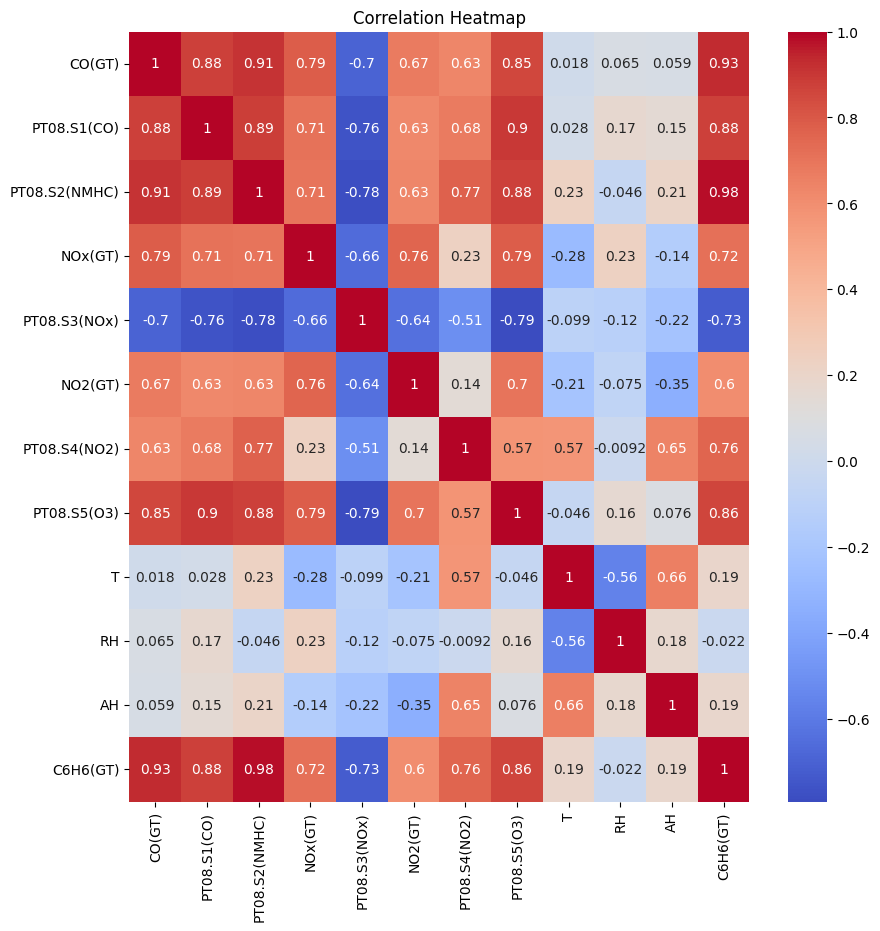

In [ ]:
# Correlation heat map
corr = air_qual.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

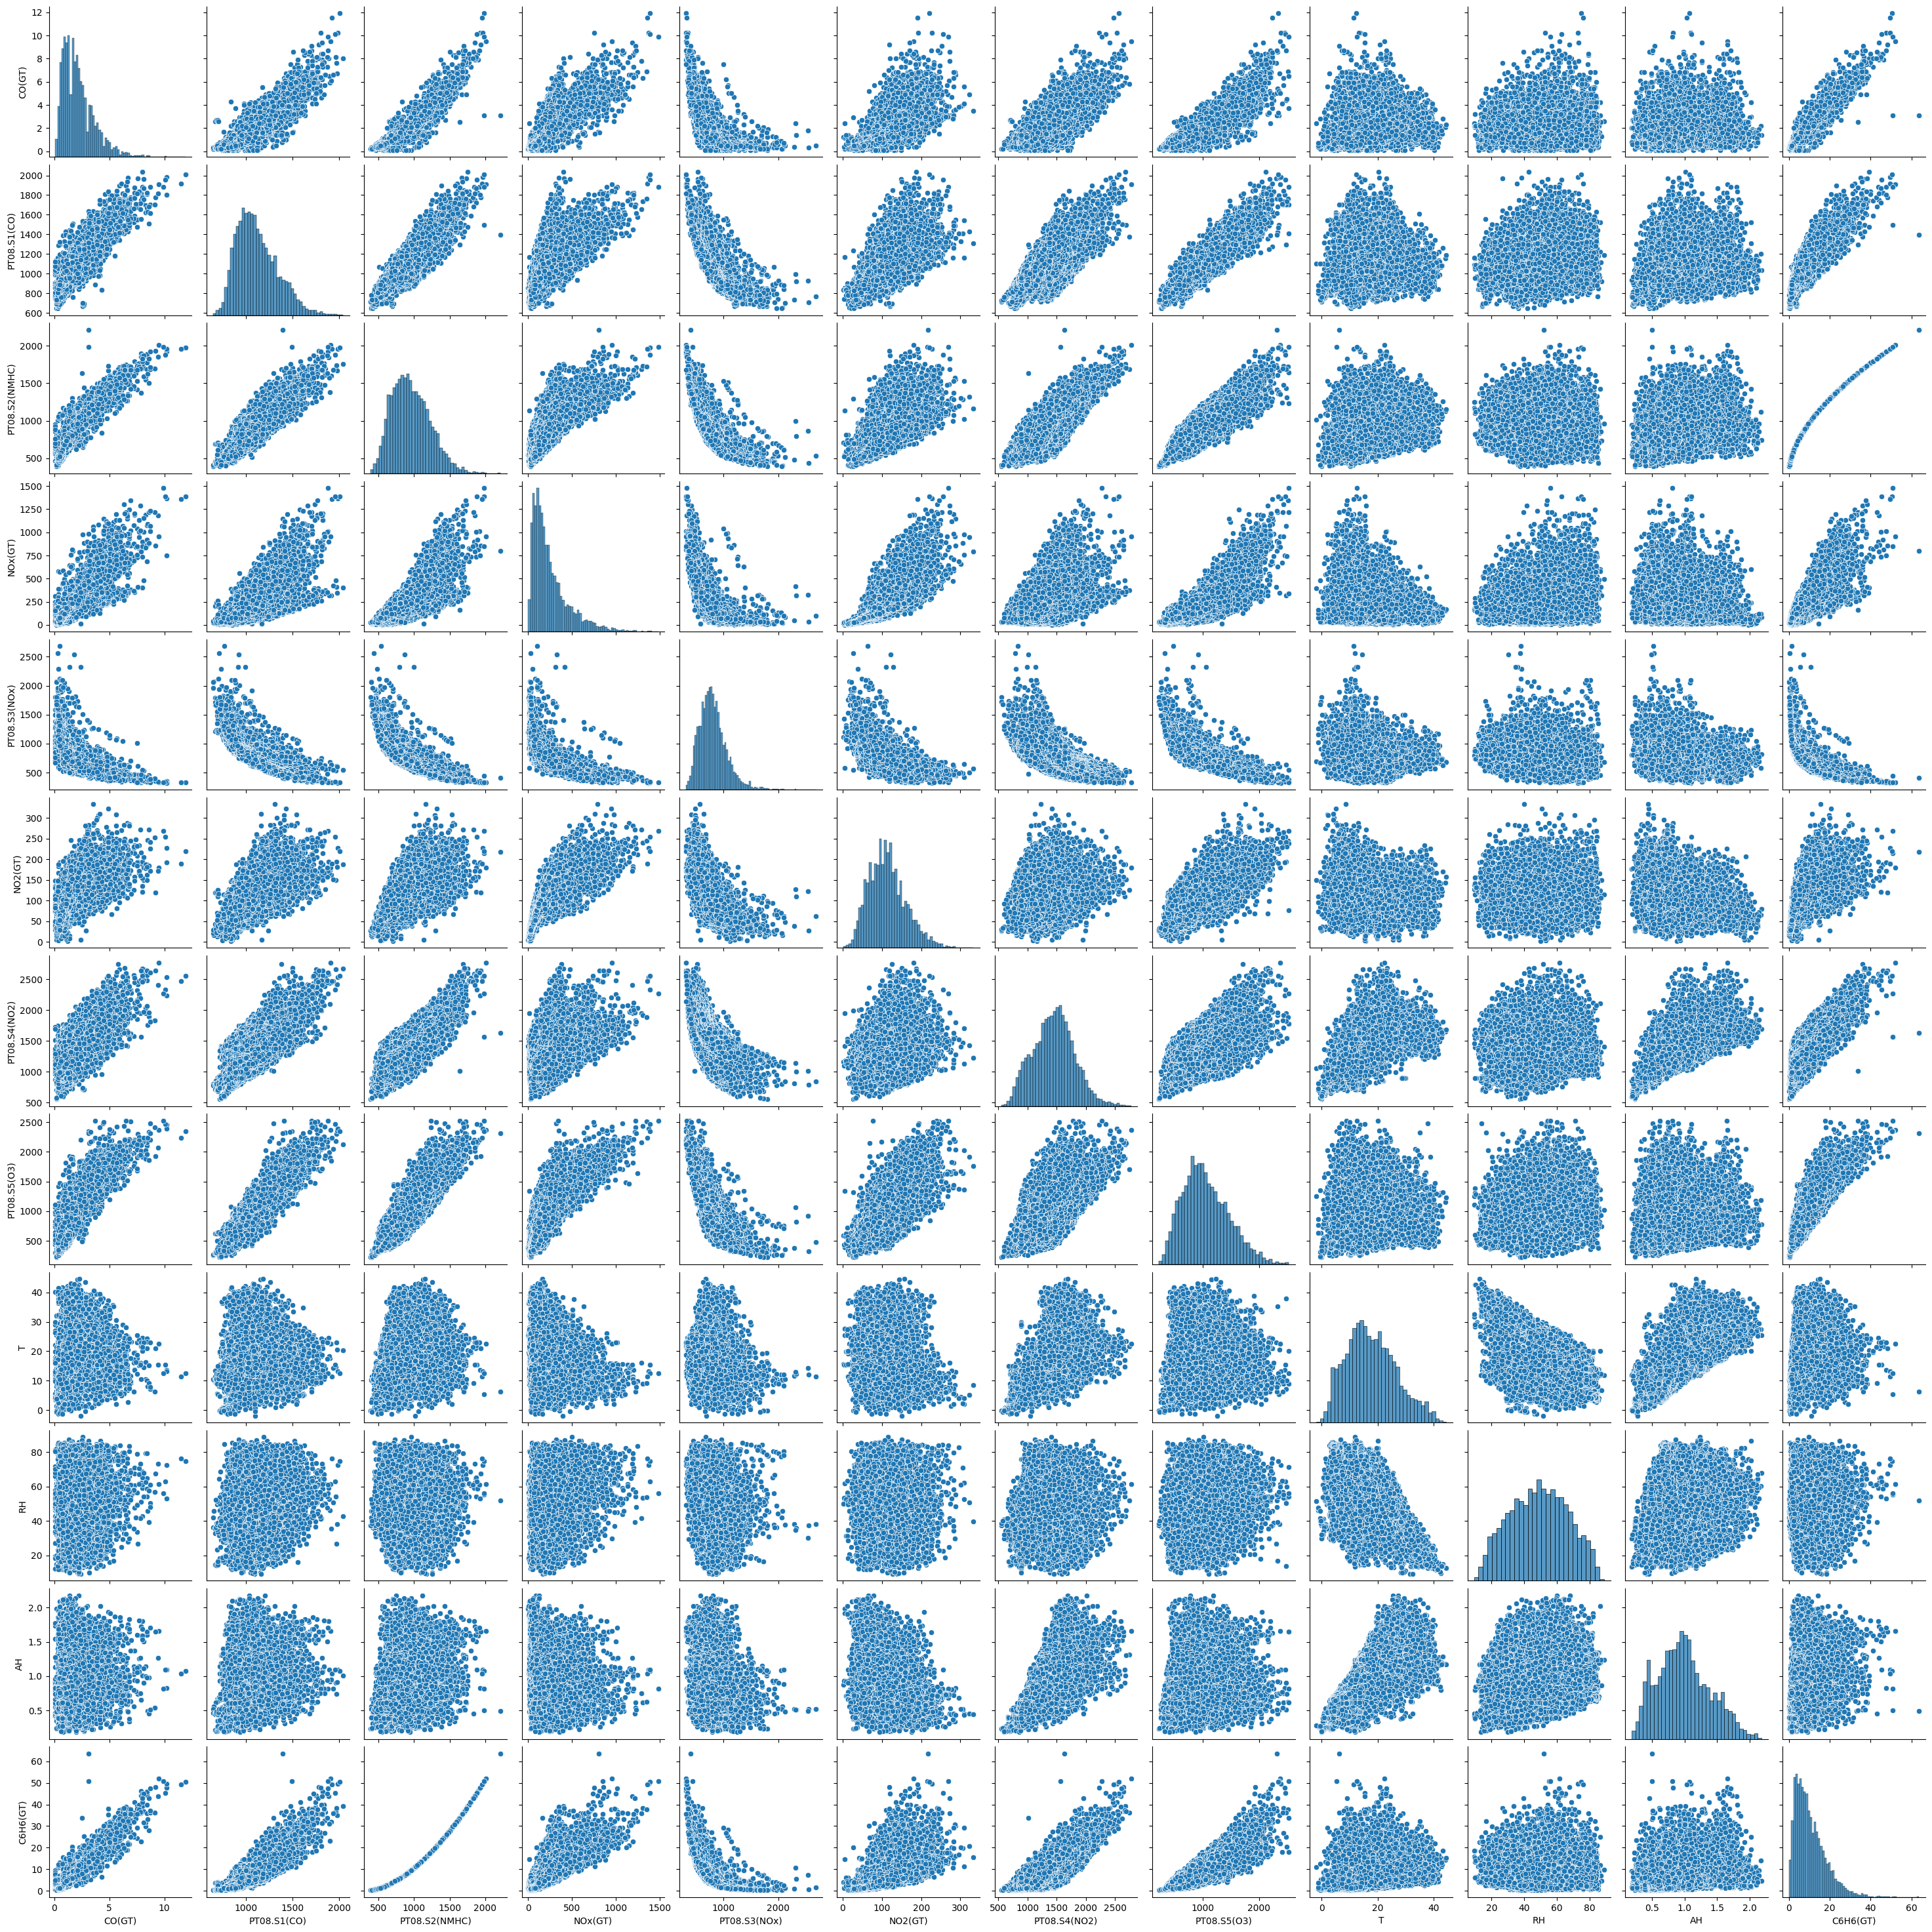

In [ ]:
# Pair plots
sns.pairplot(data = air_qual)

The correlation heatmap and pair plots both show strong relationships between many of the gases, but weak relationships between the temperature and humidity variables. We see a surprisingly strong relationship between the conventional benzene sensor and experimental NMHC sensor, which seems to be a quadratic relationship. We believe this is because benzene is a type of NMHC gas.

## Modeling

The full, conventional, and experimental models will all use the following specifications:
*   ElasticNetCV model using 5-fold cross validation.
*   Select the best $\alpha$ value from the set $\alpha \in \{0.001, 0.00278, 0.00774, 0.02154, 0.05995, 0.16681, 0.46416, 1.29155, 3.59381, 10.0\}$. This set of potential $\alpha$ values was suggested by ChatGPT.
*   Select the best l1 ratio from the set $l1 \in \{ 0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0 \}$. This set of potential l1 ratios was suggested in the [ElasticNetCV documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNetCV.html).
*   Will not use any datetime variables as covariates.
*   The same 80/20 train-test split defined in the next code section.


In [ ]:
# Train-test split
X = air_qual.drop(["Datetime", "C6H6(GT)"], axis=1)
y = air_qual["C6H6(GT)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Full model

In [ ]:
# ridge regression
alpha_values = [0.001, 0.00278, 0.00774, 0.02154, 0.05995, 0.16681, 0.46416, 1.29155, 3.59381, 10.0]
l1_ratio_values = [0.1,0.5,0.7,0.9,0.95,0.99,1.0]
full_model_ridge = RidgeCV(alphas=alpha_values, cv=5)
full_model_ridge.fit(X_train, y_train)

# make prediction
y_full_pred_ridge = full_model_ridge.predict(X_test)
# compute R2, and MSE
R2_ridge = r2_score(y_test, y_full_pred_ridge)
MSE_ridge = mean_squared_error(y_test, y_full_pred_ridge)
# make them into a dataframe
data_ridge = {
    "Best_alpha": [full_model_ridge.alpha_],
    "R square": [R2_ridge],
    "MSE": [MSE_ridge]
}
full_metric_table_ridge = pd.DataFrame(data_ridge)
full_metric_table_ridge

,Best_alpha,R square,MSE
0,3.59381,0.974621,1.386328


In [ ]:
# LASSO regression
full_model_lasso = LassoCV(alphas=alpha_values, cv=5)
full_model_lasso.fit(X_train, y_train)

# make prediction
y_full_pred_lasso = full_model_lasso.predict(X_test)
# compute R2, and MSE
R2_lasso = r2_score(y_test, y_full_pred_lasso)
MSE_lasso = mean_squared_error(y_test, y_full_pred_lasso)
# make them into a dataframe
data_lasso = {
    "Best_alpha": [full_model_lasso.alpha_],
    "R square": [R2_lasso],
    "MSE": [MSE_lasso]
}
full_metric_table_lasso = pd.DataFrame(data_lasso)
full_metric_table_lasso

,Best_alpha,R square,MSE
0,0.001,0.974606,1.387158


In [ ]:
# Elastic net regression
alpha_values = [0.001, 0.00278, 0.00774, 0.02154, 0.05995, 0.16681, 0.46416, 1.29155, 3.59381, 10.0]
l1_ratio_values = [0.1,0.5,0.7,0.9,0.95,0.99,1.0]
full_model = ElasticNetCV(alphas = alpha_values, l1_ratio = l1_ratio_values, cv=5, random_state=42)
full_model.fit(X_train, y_train)

# make prediction
y_full_pred = full_model.predict(X_test)
# compute R2, and MSE
R2_elastic = r2_score(y_test, y_full_pred)
MSE_elastic = mean_squared_error(y_test, y_full_pred)
# make them into a dataframe
data = {
    "Best_alpha": [full_model.alpha_],
    "l1_ratio": [full_model.l1_ratio_],
    "R square": [R2_elastic],
    "MSE": [MSE_elastic]
}
full_metric_table = pd.DataFrame(data)
full_metric_table

,Best_alpha,l1_ratio,R square,MSE
0,0.001,0.1,0.974617,1.386564


In [ ]:
metric = {
    "Regression": ["Ridge", "LASSO", "Elastic"],
    "R2": [R2_ridge, R2_lasso, R2_elastic],
    "MSE": [MSE_ridge, MSE_lasso, MSE_elastic]
}
metric_table = pd.DataFrame(metric)
metric_table

,Regression,R2,MSE
0,Ridge,0.974621,1.386328
1,LASSO,0.974606,1.387158
2,Elastic,0.974617,1.386564


Although the elastic net model does not have the best $R^2$ and MSE of the three models, we decided to procede with using an elastic net to create models for the conventional and experimental sensor groups because it has variable selection capabilities. The variable selection will help us mitigate the effects of multicollinearity in this data set.

#### Residual plot
To check constant variance assumption

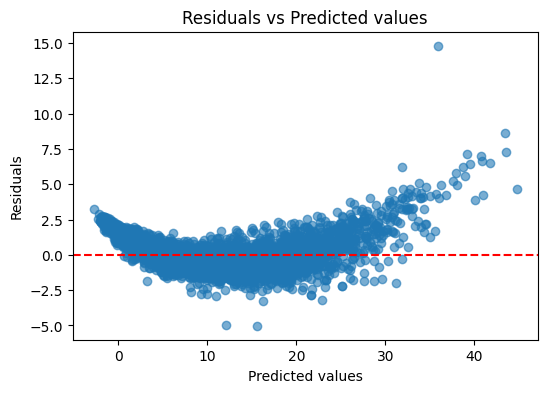

In [ ]:
y_full_pred_train = full_model.predict(X_train)
residual_full = y_train - y_full_pred_train

# residuals vs predicted values
plt.figure(figsize=(6,4))
plt.scatter(y_full_pred_train, residual_full, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted values")
plt.show()

#### Multicollinearity
Multicollinearity occurs when the features are not independent to each other. Having multicollinearity in a MLR model makes the interpretation complicated, and causes the parameter estimates to be unreliable.

One approach to check multicollinearity is by computing **variance inflation factor (VIF)**. It represents how much the variance of the parameter estimates is inflated compared to its corresponding simple linear regression variance.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame({
    "feature": list(X.columns),
    "coefficient": list(full_model.coef_),
    "VIF": [variance_inflation_factor(X, i) for i in range(X.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data

,feature,coefficient,VIF
2,PT08.S2(NMHC),0.023612,312.792480
6,PT08.S4(NO2),0.001644,275.856695
1,PT08.S1(CO),0.000349,193.875001
10,AH,0.669774,75.597960
7,PT08.S5(O3),-0.000256,67.103776
8,T,-0.075989,64.803328
9,RH,-0.029273,61.512313
0,CO(GT),0.791663,28.935560
5,NO2(GT),-0.011151,25.598753
4,PT08.S3(NOx),0.002422,18.578976


NMHC stands for non-methane hydrocarbons. It is a category of hydrocarbon gases excluding methane (CH4). Benzene (C6H6) is a NMHC gas that can be captured by the NMHC sensors. This explains the high correlation (0.98) between NMHC and C6H6 in our data. However, the high VIF of the features implies strong multicollinearity that makes the parameter estimates unreliable. The variance of the estimates is inflated, making the prediction very sensitive to any change in the data or the model.

### Conventional Sensor Group Model

In [ ]:
# Select conventional sensors from the X_train and X_test dataframes
X_train_con = X_train[["CO(GT)", "NOx(GT)", "NO2(GT)"]]
X_test_con = X_test[["CO(GT)", "NOx(GT)", "NO2(GT)"]]

# Fit the model
en_con = ElasticNetCV(alphas=alpha_values,
                      l1_ratio=l1_ratio_values,
                      cv = 5,
                      random_state=42)
en_con.fit(X_train_con, y_train)
en_con_pred = en_con.predict(X_test_con)

# Compile metrics
metrics_con = pd.DataFrame()
metrics_con["alpha"] = [en_con.alpha_]
metrics_con["l1_ratio"] = [en_con.l1_ratio_]
metrics_con["r2_score"] = [r2_score(y_test, en_con_pred)]
metrics_con["mean_squared_error"] = [mean_squared_error(y_test, en_con_pred)]
metrics_con

,alpha,l1_ratio,r2_score,mean_squared_error
0,0.001,1.0,0.85397,8.244195


#### Residual Plot for the Conventional Sensor Group

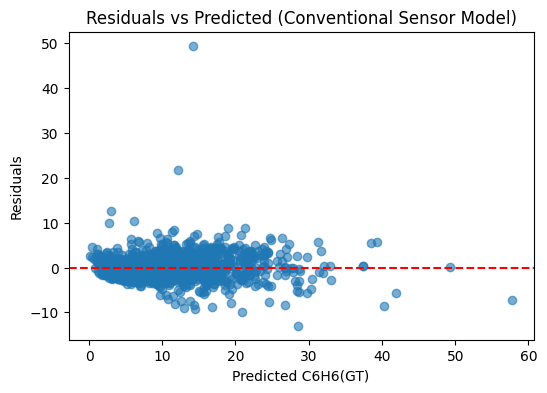

In [ ]:
# Residual plot for Experimental model
resid_con = y_test - en_con_pred
plt.figure(figsize=(6,4))
plt.scatter(en_con_pred, resid_con, alpha=0.6)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted C6H6(GT)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Conventional Sensor Model)")
plt.show()

#### Multicollinearity for Conventional Sensor Group

In [ ]:
vif_con_data = pd.DataFrame({
    "feature": list(X_train_con.columns),
    "coefficient": list(en_con.coef_),
    "VIF": [variance_inflation_factor(X_train_con, i) for i in range(X_train_con.shape[1])]
}).sort_values("VIF", ascending=False)

vif_con_data

,feature,coefficient,VIF
0,CO(GT),4.981356,8.543670
1,NOx(GT),-0.000409,7.408777
2,NO2(GT),-0.006359,6.923471


The residuals plot does not show a clear curved pattern like the full model and has VIF scores that are less than 10, so it seems to meet the assumptions for a linear model more succesfully than the full model and avoids multi-collinearity. However, the model has worse $R^2$ and MSE than the full model. It is also not a useful model in the context of this problem.

### Experimental Sensor Group Model

In [ ]:
# Select experimental sensors and meteorological variables
X_train_exp = X_train[["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
                       "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"]]
X_test_exp  = X_test[["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
                      "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"]]

# Fit the model
en_exp = ElasticNetCV(alphas=alpha_values, l1_ratio=l1_ratio_values, cv=5, random_state=42)
en_exp.fit(X_train_exp, y_train)

# Make predictions
en_exp_pred = en_exp.predict(X_test_exp)

# Compute metrics
metrics_exp = pd.DataFrame({
    "alpha": [en_exp.alpha_],
    "l1_ratio": [en_exp.l1_ratio_],
    "r2_score": [r2_score(y_test, en_exp_pred)],
    "mean_squared_error": [mean_squared_error(y_test, en_exp_pred)]
})

# Display results
metrics_exp

,alpha,l1_ratio,r2_score,mean_squared_error
0,0.001,1.0,0.971622,1.602104


#### Residual Plot for Experimental Sensor Group

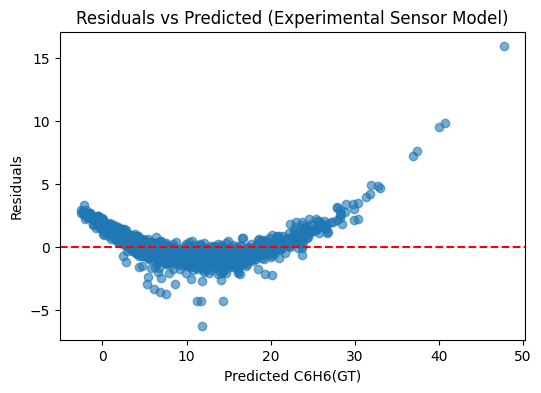

In [ ]:
# Residual plot for Experimental model
resid_exp = y_test - en_exp_pred
plt.figure(figsize=(6,4))
plt.scatter(en_exp_pred, resid_exp, alpha=0.6)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted C6H6(GT)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Experimental Sensor Model)")
plt.show()

#### Multicollinearity for Experimental Sensor Group

In [ ]:
# Variance Inflation Factor (check multi-collinearity)
vif_exp = pd.DataFrame()
vif_exp["feature"] = X_train_exp.columns
vif_exp["VIF"] = [variance_inflation_factor(X_train_exp.values, i)
                  for i in range(X_train_exp.shape[1])]
vif_exp.sort_values("VIF", ascending=False)

,feature,VIF
1,PT08.S2(NMHC),184.906484
0,PT08.S1(CO),179.801259
3,PT08.S4(NO2),147.972832
7,AH,69.495125
4,PT08.S5(O3),62.709651
6,RH,54.419850
5,T,53.739370
2,PT08.S3(NOx),16.693667


The experimental model used PT08 experimental sensors (S1–S5) and meteorological variables (T, RH, AH) to predict benzene concentration C6H6(GT). ElasticNet regression (α = 0.001, l1_ratio = 1.0) was applied without datetime features or numerical imputation. The test R² = 0.97 and MSE = 1.75 indicate excellent fit, with only slight underestimation at high concentrations.
The residual plot for the experimental sensor model shows that most residuals cluster around zero, indicating that the model’s predictions are generally unbiased across the range of benzene concentrations.
Large VIFs indicate severe multicollinearity, meaning these sensor readings are strongly correlated with each other， but ElasticNet regularization effectively mitigates this. Such correlation is expected, since the PT08 sensors measure chemically related gases and are influenced by similar environmental conditions. In contrast, meteorological variables (T, RH, and AH) have relatively low VIF values (< 80), suggesting that they contribute unique information beyond the sensor signals.
Overall, the experimental sensors combined with meteorological factors can accurately and stably predict benzene levels, achieving performance close to the full model.

## Time Series Exploration

In [ ]:
# Unique days overall + per month (from strict-cleaned air_qual)
aq = air_qual.copy()
aq["Datetime"] = pd.to_datetime(aq["Datetime"], errors="coerce")
aq = aq.dropna(subset=["Datetime"]).sort_values("Datetime")

# Overall unique days and span
unique_days = aq["Datetime"].dt.normalize().nunique()
print("Unique days:", unique_days)
print("Date range:", aq["Datetime"].min(), "→", aq["Datetime"].max())

# Per-month unique-day counts
days_by_month = (
    aq["Datetime"].dt.normalize()
      .groupby(aq["Datetime"].dt.to_period("M")).nunique()
      .rename("unique_days")
)
display(days_by_month)

Unique days: 341
Date range: 2004-03-10 18:00:00 → 2005-04-04 14:00:00


,unique_days
Datetime,
2004-03,22
2004-04,24
2004-05,29
2004-06,27
2004-07,26
2004-08,23
2004-09,25
2004-10,20
2004-11,29


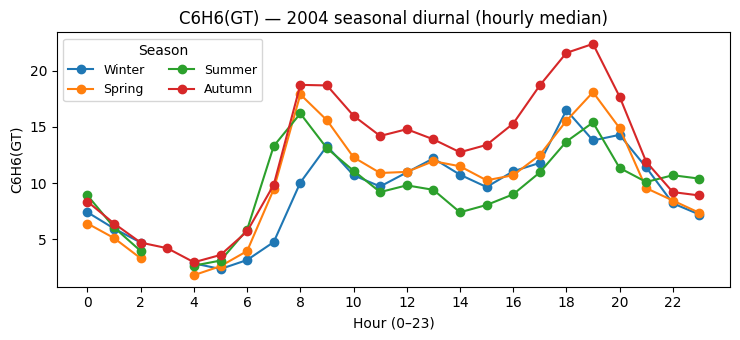

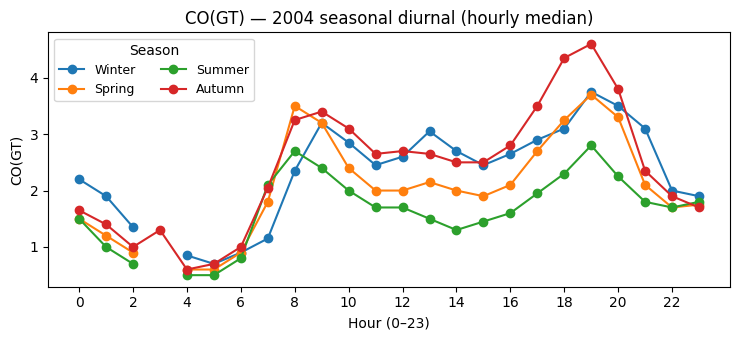

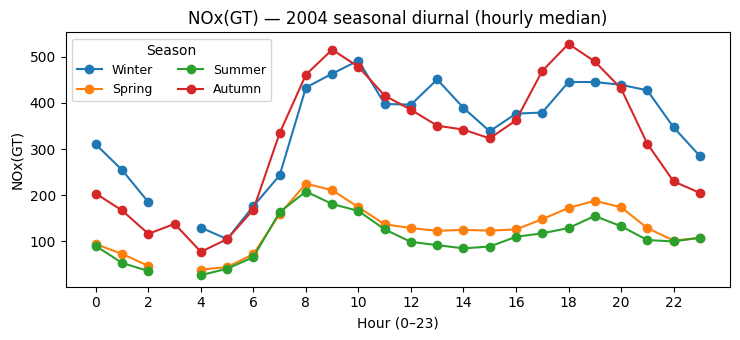

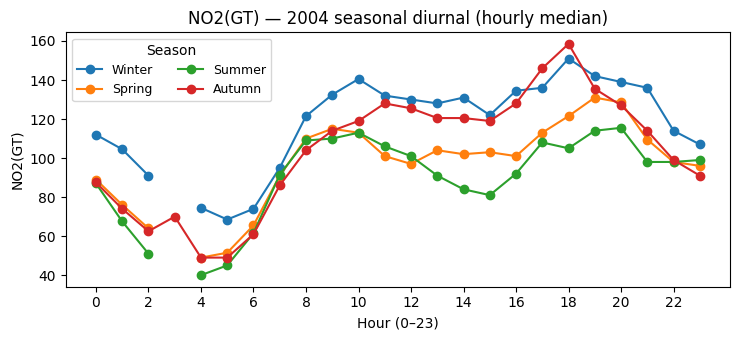

In [ ]:
# Seasonal diurnal curves (2004) — ALL available GT gases (hourly medians)
# Prep 2004 slice with a Datetime index
aq = air_qual.copy()
aq["Datetime"] = pd.to_datetime(aq["Datetime"], errors="coerce")
aq = aq.dropna(subset=["Datetime"]).set_index("Datetime").sort_index()
d04 = aq.loc["2004"]

# Season + hour tags
def season_from_month(m):
    if m in (12,1,2):  return "Winter"
    if m in (3,4,5):   return "Spring"
    if m in (6,7,8):   return "Summer"
    return "Autumn"

d04["season"] = d04.index.month.map(season_from_month)
d04["hour"]   = d04.index.hour
seasons = ["Winter","Spring","Summer","Autumn"]

# Which GT gases exist?
gt_cols = [c for c in ["C6H6(GT)","CO(GT)","NOx(GT)","NO2(GT)"] if c in d04.columns]
assert gt_cols, "No GT gas columns found."

# Plot hourly median per season for each gas
for col in gt_cols:
    g = (d04[["season","hour",col]]
         .dropna()
         .groupby(["season","hour"])[col]
         .median()
         .unstack("hour")
         .reindex(seasons))

    plt.figure(figsize=(7.5,3.5))
    for s in seasons:
        if s in g.index:
            plt.plot(g.columns, g.loc[s].values, marker="o", lw=1.5, label=s)
    plt.title(f"{col} — 2004 seasonal diurnal (hourly median)")
    plt.xlabel("Hour (0–23)"); plt.ylabel(col)
    plt.xticks(range(0,24,2)); plt.legend(ncol=2, fontsize=9, title="Season")
    plt.tight_layout(); plt.show()


In [ ]:
# Peak hour per season for each GT gas in 2004
aq = air_qual.copy()
aq["Datetime"] = pd.to_datetime(aq["Datetime"], errors="coerce")
d04 = (aq.dropna(subset=["Datetime"])
         .set_index("Datetime")
         .loc["2004"]
         .copy())

def season_from_month(m):
    if m in (12,1,2):  return "Winter"
    if m in (3,4,5):   return "Spring"
    if m in (6,7,8):   return "Summer"
    return "Autumn"

d04["season"] = d04.index.month.map(season_from_month)
d04["hour"]   = d04.index.hour

gt_cols = [c for c in ["C6H6(GT)","CO(GT)","NOx(GT)","NO2(GT)"] if c in d04.columns]

rows = []
for col in gt_cols:
    med = (d04[["season","hour", col]]
           .dropna()
           .groupby(["season","hour"])[col]
           .median()
           .unstack("hour"))
    for s in ["Winter","Spring","Summer","Autumn"]:
        if s in med.index:
            h = int(med.loc[s].idxmax())
            rows.append({"gas": col, "season": s, "peak_hour": h,
                         "median_at_peak": float(med.loc[s, h])})

summary = pd.DataFrame(rows).sort_values(["gas","season"])
summary


,gas,season,peak_hour,median_at_peak
3,C6H6(GT),Autumn,19,22.40
1,C6H6(GT),Spring,19,18.10
2,C6H6(GT),Summer,8,16.20
0,C6H6(GT),Winter,18,16.50
7,CO(GT),Autumn,19,4.60
5,CO(GT),Spring,19,3.70
6,CO(GT),Summer,19,2.80
4,CO(GT),Winter,19,3.75
15,NO2(GT),Autumn,18,158.50
13,NO2(GT),Spring,19,131.00


In [ ]:
# Season×Hour model (2004), using existing d04['season'], d04['hour']
# Ridge Regression Model for time series model
y = d04["C6H6(GT)"].dropna()
X = d04.loc[y.index, ["season","hour"]].astype(str)
X["s_h"] = X["season"] + "_" + X["hour"]
Xd = pd.get_dummies(X["s_h"], drop_first=True)

# use season-complete split point
split_idx = y.index.get_loc("2004-12-09 21:00:00")
Xtr, Xte = Xd.iloc[:split_idx], Xd.iloc[split_idx:]
ytr, yte = y.iloc[:split_idx], y.iloc[split_idx:]

model = Ridge(alpha=1.0).fit(Xtr, ytr)
pred  = model.predict(Xte)
print(f"S×H + Ridge | R²={r2_score(yte,pred):.3f}  MAE={mean_absolute_error(yte,pred):.3f}")

S×H + Ridge | R²=0.282  MAE=4.659


Season and hour do change the pattern a little, but not a lot. With a simple Season × Hour model (Ridge), we explain only about 25–30% of benzene changes. The big up-and-down movements come from short-term things (traffic, mixing, wind), not just season or hour. So seasonal pattern exists, but alone it’s not strong enough to predict benzene well.

## Next Steps

* Address the multi-collinearity in the experimental sensor model since the VIF scores are so high
* Fix the model mis-specification in the experimental model since we see a curved relationship in the residual plots
* Attempt to incorporate time-related predictors into the model based on the results of the exploration above
* Variable selection using  Elastic Net penalties
* Interested in applying unsupervised learning methods to cluster the data and create air quality levels

## Team Contributions
* All members did data cleaning and EDA
* Nan fit the full model and computed VIF
* Teddie fit the conventional model and computed VIF
* Alysia fit the experimental model and computed VIF
* Kajal did the time series exploration